In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from evaluation.portfolio import portfolio_roi, portfolio_kelly, portfolio_breakdown

abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/abt.parquet')
ts = pd.read_parquet('C:/Users/twluc/frame/01_data/02_features/team_season.parquet')
final = pd.read_parquet('C:/Users/twluc/frame/01_data/02_features/team_season_final.parquet')
thr = json.load(open('C:/Users/twluc/frame/01_data/02_features/thresholds.json'))

In [2]:
final = (
    final
    .sort_values(['league', 'season', 'season_points_avg', 'season_goals_diff_avg'],
                 ascending=[True, True, False, False])
    .assign(standing=lambda df: df.groupby(['league', 'season']).cumcount() + 1)
)

In [9]:
def plot_totaldiff_scatter(df, group):
    
    fig, ax = plt.subplots(figsize=(9, 7))
    for grp_val, grp in df.groupby(group):
        ax.scatter(grp['season_shots_on_target_total_avg'], grp['season_shots_on_target_diff_avg'], label=grp_val, alpha=0.6, s=20)

    ax.axvline(thr['shots_on_target_total_p33'], color='gray', linewidth=0.6, linestyle='--')
    ax.axvline(thr['shots_on_target_total_p67'], color='gray', linewidth=0.6, linestyle='--')
    ax.axhline(thr['shots_on_target_diff_p33'],  color='gray', linewidth=0.6, linestyle='--')
    ax.axhline(thr['shots_on_target_diff_p67'],  color='gray', linewidth=0.6, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.8)

    ax.set_xlim(6, 12) 
    ax.set_ylim(-5,5)

    ax.set_xlabel('shots_on_target total avg'); ax.set_ylabel('shots_on_target diff avg')
    ax.legend(markerscale=2, fontsize=8)
    plt.tight_layout(); plt.show()


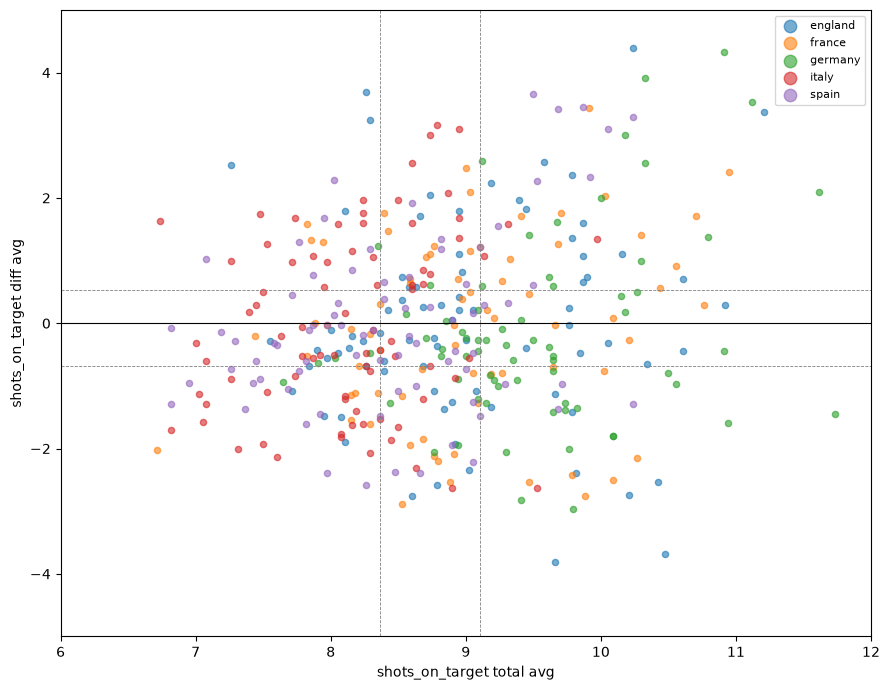

In [10]:
plot_totaldiff_scatter(final,'league')

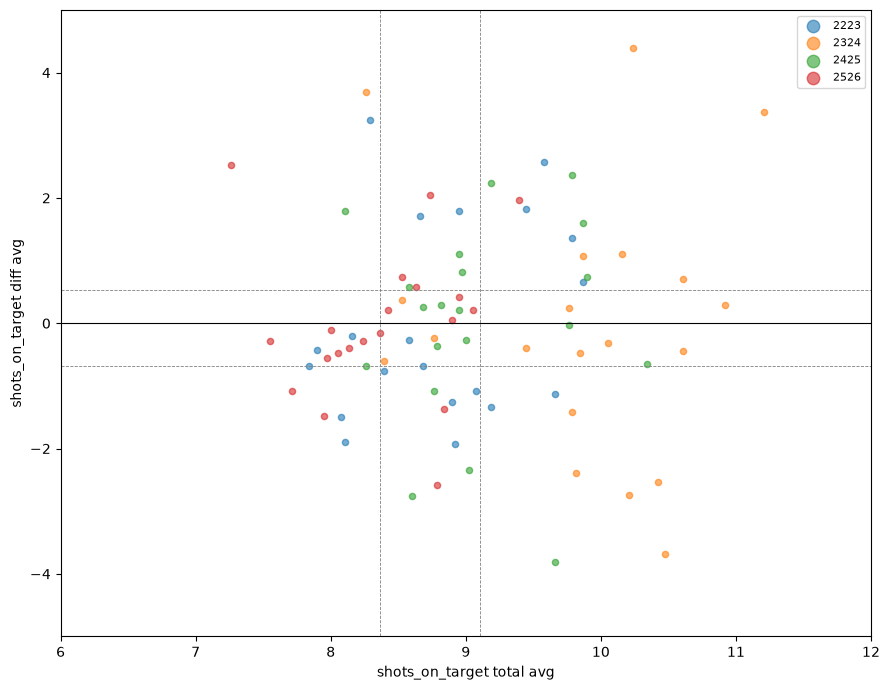

In [11]:
england = final[final['league']=='england']
plot_totaldiff_scatter(england,'season')

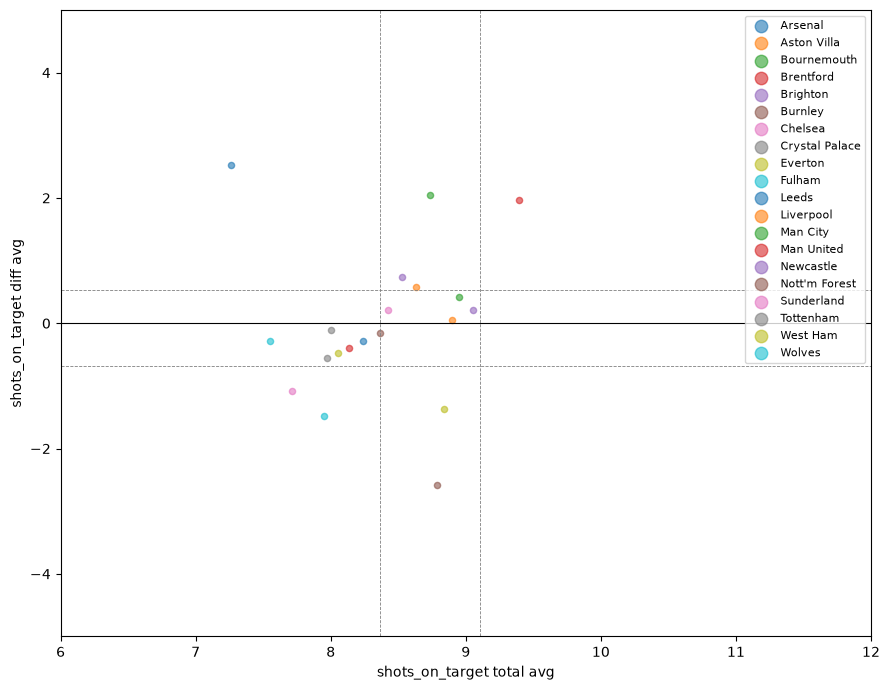

In [12]:
england2526 = final.query("league == 'england' and season == '2526'")
plot_totaldiff_scatter(england2526,'team')

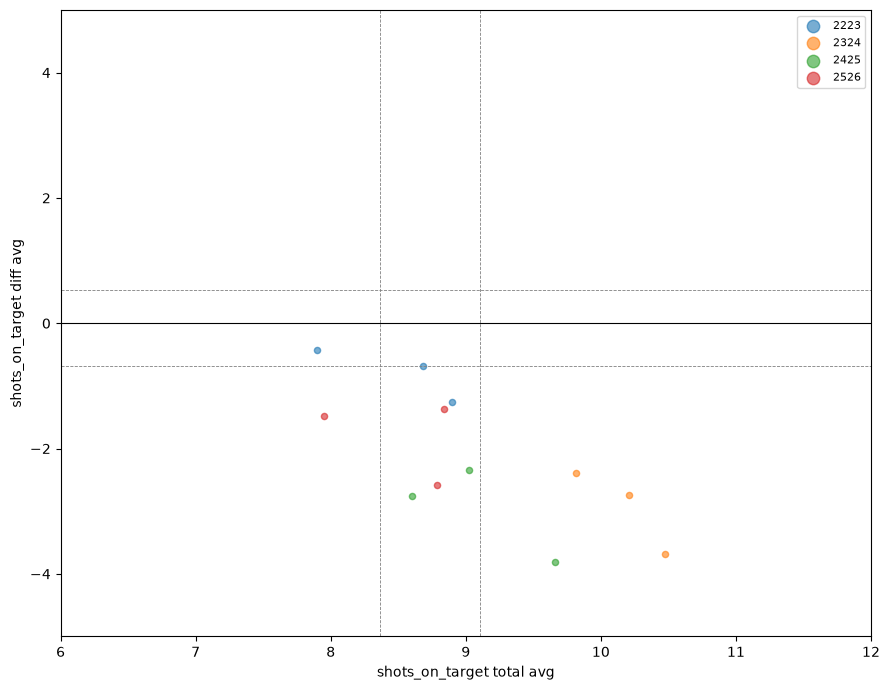

In [13]:
query = "league == 'england' and standing >= 18"
plot_totaldiff_scatter(final.query(query),'season')

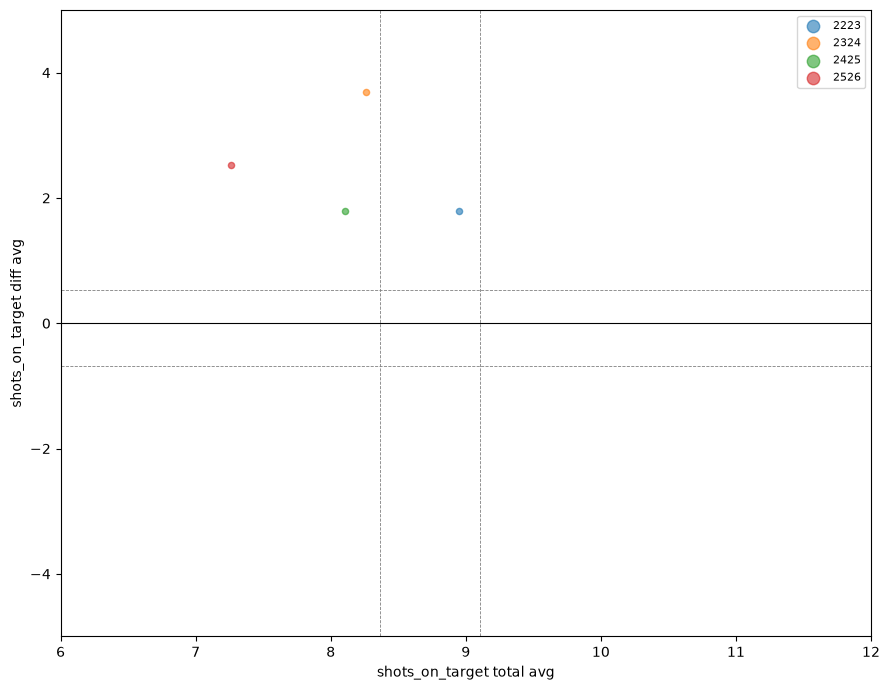

In [14]:
query = "team == 'Arsenal'"
plot_totaldiff_scatter(final.query(query),'season')

In [27]:
final.groupby(['league', 'season_shots_on_target_total_cat3q']).size().unstack()[['low','medium','high']]

season_shots_on_target_total_cat3q,low,medium,high
league,,,
england,18,32,30
france,17,27,30
germany,5,17,50
italy,50,26,4
spain,36,27,17


In [28]:
final.groupby(['league', 'season_shots_on_target_diff_cat3q']).size().unstack()[['low','medium','high']]

season_shots_on_target_diff_cat3q,low,medium,high
league,,,
england,24,30,26
france,26,20,28
germany,26,27,19
italy,29,18,33
spain,26,31,23


In [31]:
sub = abt[abt['hmt_game_number'] > 8]
cols = ['hmt_season_shots_on_target_total_cat2m', 'hmt_season_shots_on_target_diff_cat2m',
        'awt_season_shots_on_target_total_cat2m', 'awt_season_shots_on_target_diff_cat2m']

groups = {k: g for k, g in sub.groupby(cols)}
results = {k: portfolio_roi(g['mrkt_draw_impl'], g['t_draw_flg']) for k, g in groups.items()}
for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
    pval = binomtest(r['wins'], r['n_bets'], groups[k]['mrkt_draw_impl'].mean()).pvalue
    print(k, f"roi={r['roi']:.3f}  n={r['n_bets']}  p={pval:.3f}")


('low', 'negative', 'low', 'negative') roi=0.122  n=603  p=0.051
('high', 'negative', 'low', 'negative') roi=0.170  n=323  p=0.057
('low', 'positive', 'low', 'negative') roi=0.068  n=443  p=0.437
('high', 'negative', 'high', 'negative') roi=0.049  n=422  p=0.544
('high', 'negative', 'high', 'positive') roi=0.013  n=361  p=0.903
('low', 'negative', 'high', 'negative') roi=-0.039  n=329  p=0.714
('high', 'positive', 'high', 'negative') roi=-0.056  n=359  p=0.641
('low', 'negative', 'high', 'positive') roi=-0.053  n=325  p=0.612
('high', 'positive', 'low', 'positive') roi=-0.091  n=250  p=0.465
('low', 'positive', 'high', 'negative') roi=-0.156  n=195  p=0.265
('high', 'positive', 'high', 'positive') roi=-0.102  n=317  p=0.326
('high', 'negative', 'low', 'positive') roi=-0.147  n=210  p=0.213
('high', 'positive', 'low', 'negative') roi=-0.138  n=319  p=0.240
('low', 'negative', 'low', 'positive') roi=-0.123  n=492  p=0.090
('low', 'positive', 'high', 'positive') roi=-0.296  n=253  p=0.004

In [32]:
sub = abt[abt['hmt_game_number'] > 8]
cols = ['hmt_season_shots_on_target_total_cat3q', 'hmt_season_shots_on_target_diff_cat3q',
        'awt_season_shots_on_target_total_cat3q', 'awt_season_shots_on_target_diff_cat3q']

groups = {k: g for k, g in sub.groupby(cols)}
results = {k: portfolio_roi(g['mrkt_draw_impl'], g['t_draw_flg']) for k, g in groups.items()}
for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
    pval = binomtest(r['wins'], r['n_bets'], groups[k]['mrkt_draw_impl'].mean()).pvalue
    print(k, f"roi={r['roi']:.3f}  n={r['n_bets']}  p={pval:.3f}")


('high', 'high', 'medium', 'low') roi=0.718  n=81  p=0.005
('high', 'medium', 'medium', 'low') roi=0.879  n=39  p=0.003
('low', 'low', 'medium', 'low') roi=0.294  n=85  p=0.097
('high', 'low', 'medium', 'low') roi=0.306  n=72  p=0.114
('medium', 'high', 'low', 'medium') roi=0.359  n=68  p=0.116
('high', 'medium', 'high', 'high') roi=0.220  n=97  p=0.237
('medium', 'medium', 'high', 'high') roi=0.237  n=73  p=0.229
('high', 'medium', 'high', 'medium') roi=0.215  n=69  p=0.277
('low', 'medium', 'low', 'low') roi=0.132  n=102  p=0.383
('medium', 'medium', 'low', 'medium') roi=0.190  n=69  p=0.354
('high', 'low', 'low', 'low') roi=0.225  n=53  p=0.293
('low', 'high', 'low', 'medium') roi=0.157  n=87  p=0.387
('low', 'medium', 'low', 'medium') roi=0.078  n=131  p=0.569
('medium', 'medium', 'low', 'low') roi=0.207  n=55  p=0.363
('high', 'low', 'medium', 'medium') roi=0.158  n=68  p=0.419
('medium', 'medium', 'high', 'medium') roi=0.211  n=49  p=0.420
('high', 'medium', 'low', 'medium') roi=

In [37]:
from sklearn.cluster import KMeans

In [38]:
def cluster_roi(n_clusters, outcome='draw'):
    impl_col = f'mrkt_{outcome}_impl'
    flg_col  = f't_{outcome}_flg'

    km = KMeans(n_clusters=n_clusters, random_state=0)
    final[f'kmeans_cluster{n_clusters}'] = km.fit_predict(final[['season_shots_on_target_total_avg', 'season_shots_on_target_diff_avg']]).astype(str)
    plot_totaldiff_scatter(final, f'kmeans_cluster{n_clusters}')

    sub = abt[abt['hmt_game_number'] > 8].copy()
    sub['hmt_km'] = km.predict(sub[['hmt_season_shots_on_target_total_avg', 'hmt_season_shots_on_target_diff_avg']].rename(columns=lambda c: c.replace('hmt_', ''))).astype(str)
    sub['awt_km'] = km.predict(sub[['awt_season_shots_on_target_total_avg', 'awt_season_shots_on_target_diff_avg']].rename(columns=lambda c: c.replace('awt_', ''))).astype(str)

    groups = {k: g for k, g in sub.groupby(['hmt_km', 'awt_km'])}
    results = {k: portfolio_roi(g[impl_col], g[flg_col]) for k, g in groups.items()}
    for k, r in sorted(results.items(), key=lambda x: -x[1]['profit']):
        g = groups[k]
        pval = binomtest(r['wins'], r['n_bets'], g[impl_col].mean()).pvalue
        print(k, r, f"p={pval:.3f}")


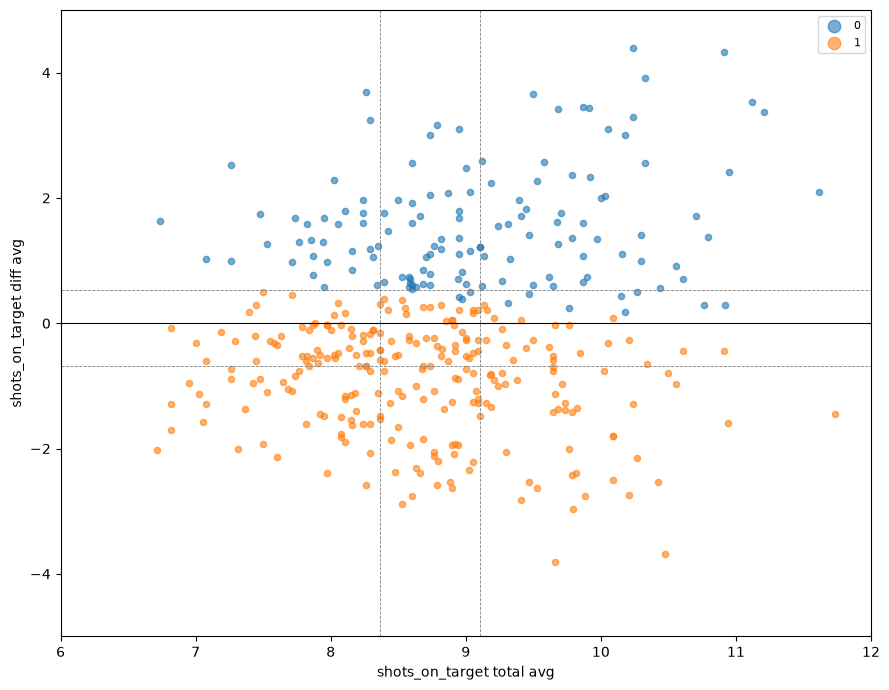

('1', '1') {'n_bets': 2177, 'capital': 621.761, 'wins': 631, 'profit': 9.239, 'roi': 0.0149} p=0.669
('0', '1') {'n_bets': 1265, 'capital': 269.318, 'wins': 256, 'profit': -13.318, 'roi': -0.0495} p=0.372
('1', '0') {'n_bets': 1312, 'capital': 343.916, 'wins': 326, 'profit': -17.916, 'roi': -0.0521} p=0.272
('0', '0') {'n_bets': 783, 'capital': 204.586, 'wins': 170, 'profit': -34.586, 'roi': -0.1691} p=0.005


In [39]:
cluster_roi(2)

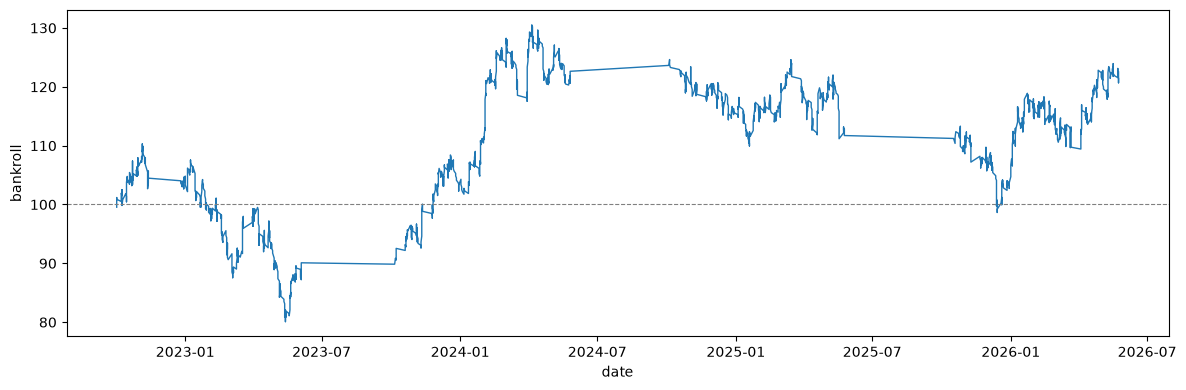

{'n_bets': 2423,
 'capital': 963.9639,
 'wins': 703,
 'profit': 22.5246,
 'roi': 0.0234,
 'bankroll_roi': 0.2252}

In [46]:
query = "hmt_game_number > 8 and hmt_season_shots_on_target_diff_cat3q != 'high' and awt_season_shots_on_target_diff_cat3q != 'high'"
sub = abt.query(query)
portfolio_kelly(sub['mrkt_draw_impl'], sub['t_draw_flg'], model_probs=sub['mrkt_draw_impl'] * 1.02, dates = sub['date'], plot = True)

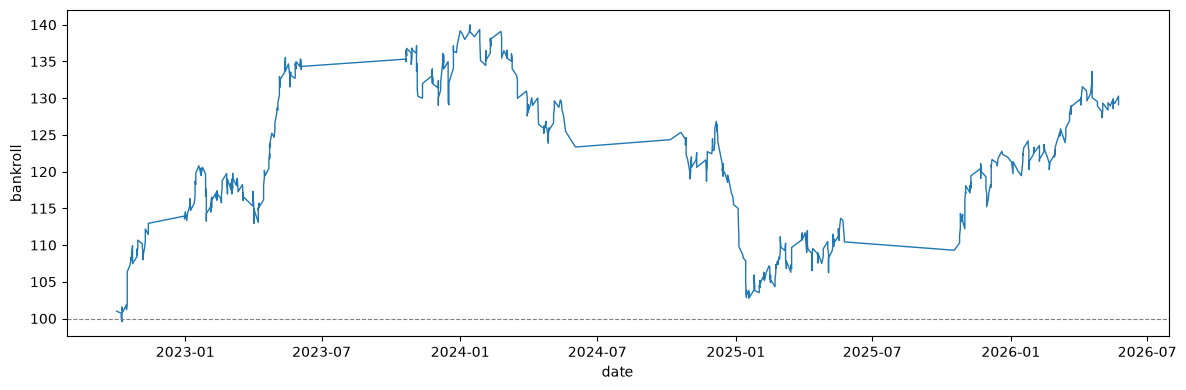

{'n_bets': 639,
 'capital': 677.9413,
 'wins': 314,
 'profit': 29.1196,
 'roi': 0.043,
 'bankroll_roi': 0.2912}

In [50]:
query = "hmt_game_number > 8 and hmt_season_shots_on_target_diff_cat3q == 'high' and awt_season_shots_on_target_diff_cat3q == 'high'"
sub = abt.query(query)
portfolio_kelly(sub['mrkt_home_impl'], sub['t_home_flg'], model_probs=sub['mrkt_home_impl'] * 1.02, dates = sub['date'], plot = True)

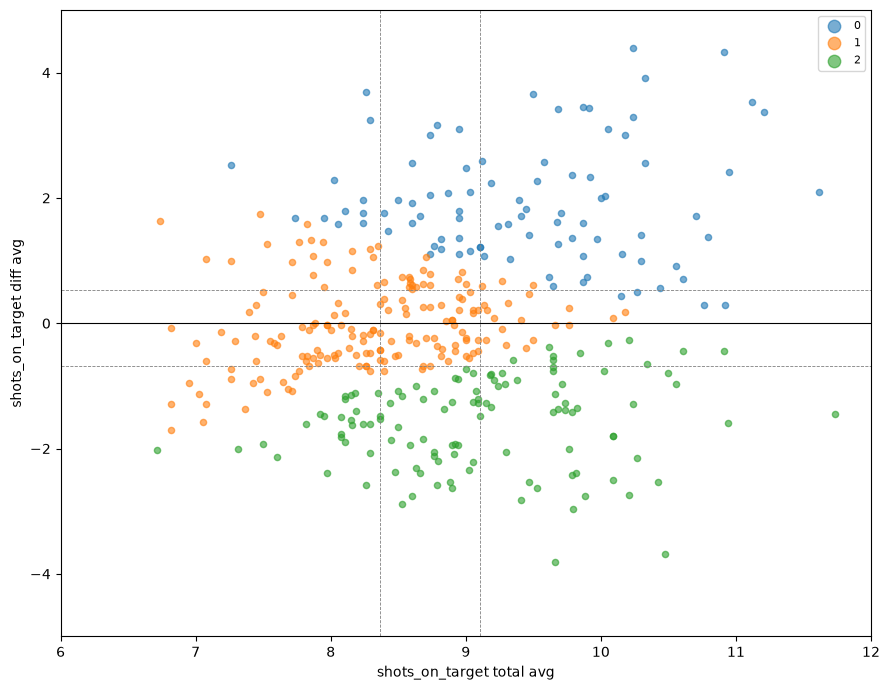

('0', '0') {'n_bets': 316, 'capital': 144.895, 'wins': 155, 'profit': 10.105, 'roi': 0.0697} p=0.259
('0', '1') {'n_bets': 603, 'capital': 388.895, 'wins': 398, 'profit': 9.105, 'roi': 0.0234} p=0.469
('0', '2') {'n_bets': 443, 'capital': 327.249, 'wins': 323, 'profit': -4.249, 'roi': -0.013} p=0.665
('2', '0') {'n_bets': 477, 'capital': 102.598, 'wins': 95, 'profit': -7.598, 'roi': -0.0741} p=0.435
('1', '0') {'n_bets': 583, 'capital': 174.46, 'wins': 161, 'profit': -13.46, 'roi': -0.0772} p=0.240
('2', '2') {'n_bets': 568, 'capital': 261.159, 'wins': 240, 'profit': -21.159, 'roi': -0.081} p=0.077
('1', '2') {'n_bets': 728, 'capital': 417.856, 'wins': 390, 'profit': -27.856, 'roi': -0.0667} p=0.039
('2', '1') {'n_bets': 751, 'capital': 263.506, 'wins': 233, 'profit': -30.506, 'roi': -0.1158} p=0.020
('1', '1') {'n_bets': 1068, 'capital': 482.41, 'wins': 434, 'profit': -48.41, 'roi': -0.1004} p=0.003


In [51]:
cluster_roi(3,'home')

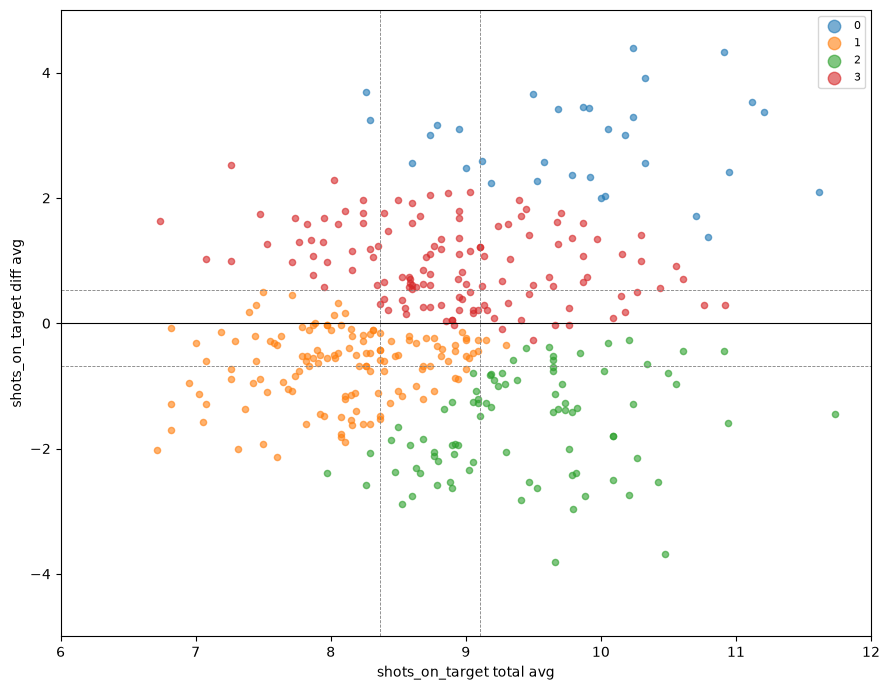

('3', '3') {'n_bets': 610, 'capital': 283.12, 'wins': 297, 'profit': 13.88, 'roi': 0.049} p=0.273
('0', '0') {'n_bets': 55, 'capital': 27.916, 'wins': 35, 'profit': 7.084, 'roi': 0.2538} p=0.060
('2', '0') {'n_bets': 159, 'capital': 27.594, 'wins': 34, 'profit': 6.406, 'roi': 0.2322} p=0.174
('3', '0') {'n_bets': 194, 'capital': 58.286, 'wins': 60, 'profit': 1.714, 'roi': 0.0294} p=0.814
('0', '1') {'n_bets': 173, 'capital': 132.445, 'wins': 132, 'profit': -0.445, 'roi': -0.0034} p=0.929
('0', '3') {'n_bets': 165, 'capital': 106.723, 'wins': 104, 'profit': -2.723, 'roi': -0.0255} p=0.684
('0', '2') {'n_bets': 149, 'capital': 119.831, 'wins': 116, 'profit': -3.831, 'roi': -0.032} p=0.410
('1', '2') {'n_bets': 410, 'capital': 213.074, 'wins': 207, 'profit': -6.074, 'roi': -0.0285} p=0.553
('1', '0') {'n_bets': 160, 'capital': 32.148, 'wins': 22, 'profit': -10.148, 'roi': -0.3157} p=0.048
('1', '3') {'n_bets': 585, 'capital': 182.789, 'wins': 172, 'profit': -10.789, 'roi': -0.059} p=0.349

In [52]:
cluster_roi(4,'home')

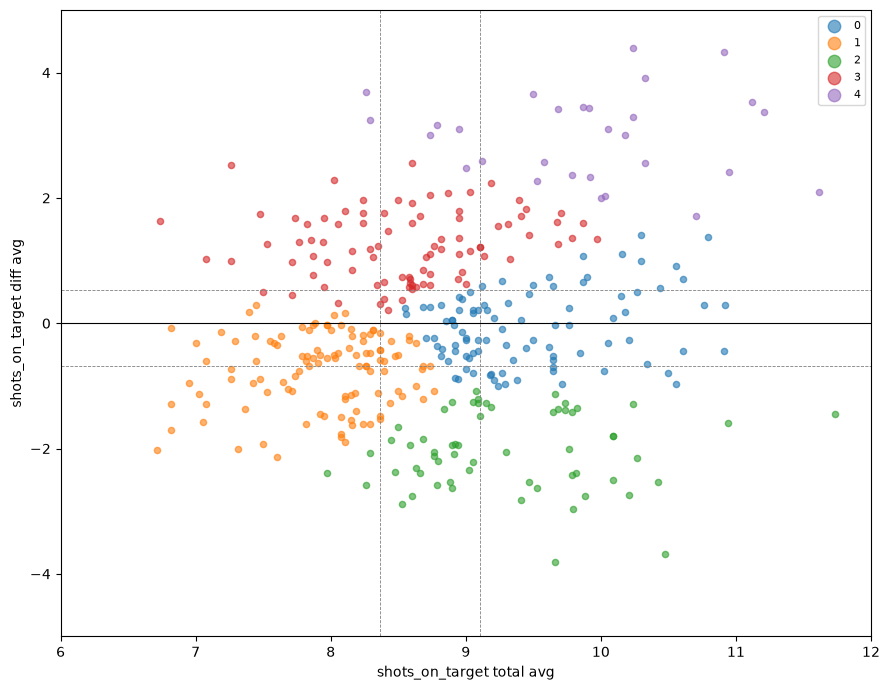

('3', '3') {'n_bets': 370, 'capital': 168.342, 'wins': 180, 'profit': 11.658, 'roi': 0.0693} p=0.230
('4', '4') {'n_bets': 51, 'capital': 24.534, 'wins': 31, 'profit': 6.466, 'roi': 0.2636} p=0.092
('1', '0') {'n_bets': 231, 'capital': 93.973, 'wins': 99, 'profit': 5.027, 'roi': 0.0535} p=0.504
('0', '3') {'n_bets': 195, 'capital': 72.238, 'wins': 77, 'profit': 4.762, 'roi': 0.0659} p=0.505
('0', '2') {'n_bets': 233, 'capital': 142.469, 'wins': 147, 'profit': 4.531, 'roi': 0.0318} p=0.591
('4', '0') {'n_bets': 121, 'capital': 89.529, 'wins': 94, 'profit': 4.471, 'roi': 0.0499} p=0.407
('0', '4') {'n_bets': 129, 'capital': 31.313, 'wins': 34, 'profit': 2.687, 'roi': 0.0858} p=0.608
('3', '0') {'n_bets': 192, 'capital': 107.599, 'wins': 110, 'profit': 2.401, 'roi': 0.0223} p=0.771
('2', '4') {'n_bets': 106, 'capital': 16.89, 'wins': 19, 'profit': 2.11, 'roi': 0.1249} p=0.595
('3', '4') {'n_bets': 114, 'capital': 35.545, 'wins': 34, 'profit': -1.545, 'roi': -0.0435} p=0.840
('4', '1') {'n

In [54]:
cluster_roi(5,'home')